# Why does the bus14 $\rightarrow$ WCCI zero-shot transfer fail?

This notebook diagnoses the **80 deterministic 50-chronic WCCI
zero-shot evaluations** of the shared candidate-action models. It
separates three questions that a single mean survival score hides:

1. Is improvement broad, or driven by a few exceptional rescues?
2. Does increasing the target candidate set change intervention
   behavior in a systematic way?
3. Which changes are most likely to improve transfer, and what
   experiment would falsify each explanation?

The analysis uses the saved episode summaries, action summaries,
target action-space metadata, and one target-trained MLP comparator.
It does **not** infer causality from correlations. Exact illegal-action,
cooldown, and logit-margin diagnoses require new traces because those
fields were not saved in the completed evaluations.


In [1]:
from pathlib import Path
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")


def find_task_dir(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        direct = candidate if candidate.name == "Topology_Task" else candidate / "Topology_Task"
        if (direct / "main.py").is_file():
            return direct
    raise FileNotFoundError("Could not locate Topology_Task")


def load_json(path):
    with Path(path).open(encoding="utf-8") as handle:
        return json.load(handle)


def local_artifact_path(path_string):
    path = Path(path_string)
    if path.is_file():
        return path.resolve()
    if path.parts and path.parts[0] == "outputs":
        return TASK_DIR / path
    if "Topology_Task" in path.parts:
        index = path.parts.index("Topology_Task")
        return TASK_DIR.joinpath(*path.parts[index + 1 :])
    return TASK_DIR / path


def save_figure(fig, stem):
    path = EXPORT_DIR / f"{stem}.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    return path


TASK_DIR = find_task_dir()
BASE_ANALYSIS_DIR = TASK_DIR / "outputs" / "analysis" / "shared_zero_shot_action_space"
RESULT_ROOT = TASK_DIR / "outputs" / "full_test_eval" / "shared"
METADATA_DIR = (
    TASK_DIR / "outputs" / "teacher_student_datasets"
    / "wcci_full2048a_90_v3" / "metadata"
)
EXPORT_DIR = TASK_DIR / "outputs" / "analysis" / "shared_zero_shot_failure_analysis"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

ACTION_ORDER = [64, 128, 256, 512, 1024]
FAMILY_COLORS = {"NL": "#4C78A8", "NLS": "#F58518"}
AGENT_COLORS = {
    "agent_0": "#4C78A8",
    "agent_1": "#F58518",
    "agent_2": "#54A24B",
    "agent_3": "#E45756",
}

print("Task directory:", TASK_DIR)
print("Exports:", EXPORT_DIR)


Task directory: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task
Exports: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/analysis/shared_zero_shot_failure_analysis


## 1. Load the episode-level evidence

The companion action-space notebook already made the strict
fingerprint join to the do-nothing baseline. Reusing that export
keeps this notebook focused on failure mechanisms while retaining an
auditable, one-row-per-model-per-chronic table.


In [2]:
episodes = pd.read_csv(BASE_ANALYSIS_DIR / "episode_level_joined.csv")
ranking = pd.read_csv(BASE_ANALYSIS_DIR / "run_ranking.csv")
difficult = pd.read_csv(BASE_ANALYSIS_DIR / "difficult_chronic_model_metrics.csv")

assert len(episodes) == 80 * 50, episodes.shape
assert episodes["run_id"].nunique() == 80
assert episodes["chronic_fingerprint"].nunique() == 50
assert (episodes.groupby("run_id").size() == 50).all()

hard = episodes.loc[episodes["cohort"] == "Do-nothing < 100%"].copy()
easy = episodes.loc[episodes["cohort"] == "Do-nothing = 100%"].copy()
assert hard["chronic_fingerprint"].nunique() == 24
assert easy["chronic_fingerprint"].nunique() == 26

best_overall_id = ranking.sort_values("overall_rank").iloc[0]["run_id"]
best_hard_mean_id = difficult.sort_values("difficult_mean_rank").iloc[0]["run_id"]
best_hard_median_id = difficult.sort_values("difficult_median_rank").iloc[0]["run_id"]

display(Markdown(
    f"Loaded **{len(episodes):,} model episodes**: 80 models × 50 chronics. "
    f"The baseline defines **{hard['chronic_fingerprint'].nunique()} difficult** "
    f"and **{easy['chronic_fingerprint'].nunique()} easy** chronics."
))


Loaded **4,000 model episodes**: 80 models × 50 chronics. The baseline defines **24 difficult** and **26 easy** chronics.

## 2. Parse action behavior and candidate cardinality

`nonidle_fraction` is the fraction of evaluated steps on which an
agent requests a non-do-nothing action. Entropy and concentration are
computed over requested non-idle action IDs. These are behavioral
summaries—not legality or execution-success measurements.


In [3]:
MODEL_RE = re.compile(
    r"_shared_(?P<pool>mean|tmean)_f(?P<features>[01])_a0h(?P<head>[01])_s(?P<seed>\d+)"
)
ACTION_RE = re.compile(r"_mk(?P<size>\d+)$")


def parse_result_factors(result_path, payload):
    directory = result_path.parent.name
    family = "NLS" if directory.startswith("NLS_") else "NL"
    size_match = ACTION_RE.search(directory)
    action_size = int(size_match.group("size")) if size_match else 256
    match = MODEL_RE.search(Path(payload["checkpoint"]).stem)
    if match is None:
        raise ValueError(f"Could not parse checkpoint: {payload['checkpoint']}")
    pool = match.group("pool")
    features = int(match.group("features"))
    head = int(match.group("head"))
    seed = int(match.group("seed"))
    run_id = f"{family}_mk{action_size}_{pool}_f{features}_a0h{head}_s{seed}"
    return run_id, family, action_size, pool, features, head, seed


agent_rows = []
for result_path in sorted(RESULT_ROOT.rglob("*.json")):
    directory = result_path.parent.name
    if "_wcci36" not in directory or not directory.startswith(("NL_", "NLS_")):
        continue
    payload = load_json(result_path)
    factors = parse_result_factors(result_path, payload)
    run_id, family, action_size, pool, features, head, seed = factors
    summary_path = local_artifact_path(payload["action_artifacts"]["action_summary_json"])
    if not summary_path.is_file():
        raise FileNotFoundError(summary_path)
    summary = load_json(summary_path)
    for agent_id, values in summary["agents"].items():
        nonidle_counts = {
            int(action_id): int(count)
            for action_id, count in values["policy_action_counts"].items()
            if int(action_id) != 0
        }
        nonidle_total = sum(nonidle_counts.values())
        if nonidle_total:
            probabilities = np.asarray(list(nonidle_counts.values()), dtype=float) / nonidle_total
            entropy_bits = float(-(probabilities * np.log2(probabilities)).sum())
            top_nonidle_share = float(probabilities.max())
            unique_nonidle_actions = len(nonidle_counts)
        else:
            entropy_bits = 0.0
            top_nonidle_share = np.nan
            unique_nonidle_actions = 0
        agent_rows.append({
            "run_id": run_id,
            "family": family,
            "action_size": action_size,
            "pool": pool,
            "features": features,
            "head": head,
            "seed": seed,
            "agent_id": agent_id,
            "n_eval_steps": int(values["n_steps"]),
            "nonidle_fraction": float(values["nonidle_fraction"]),
            "nonidle_count": int(values["nonidle_count"]),
            "unique_nonidle_actions": unique_nonidle_actions,
            "nonidle_entropy_bits": entropy_bits,
            "top_nonidle_share": top_nonidle_share,
        })

agent_behavior = pd.DataFrame(agent_rows)
assert len(agent_behavior) == 80 * 4
assert agent_behavior["run_id"].nunique() == 80

run_behavior = (
    agent_behavior.groupby(
        ["run_id", "family", "action_size", "pool", "features", "head", "seed"],
        as_index=False,
    )
    .agg(
        mean_nonidle_fraction=("nonidle_fraction", "mean"),
        max_agent_nonidle_fraction=("nonidle_fraction", "max"),
        min_agent_nonidle_fraction=("nonidle_fraction", "min"),
        mean_nonidle_entropy_bits=("nonidle_entropy_bits", "mean"),
        mean_top_nonidle_share=("top_nonidle_share", "mean"),
        mean_unique_nonidle_actions=("unique_nonidle_actions", "mean"),
    )
)
run_behavior["nonidle_imbalance"] = (
    run_behavior["max_agent_nonidle_fraction"]
    - run_behavior["min_agent_nonidle_fraction"]
)
run_behavior = run_behavior.merge(
    ranking[["run_id", "mean_survival_percent", "delta_vs_do_nothing_pp"]],
    on="run_id",
    validate="one_to_one",
).merge(
    difficult[[
        "run_id", "difficult_mean_survival_percent",
        "difficult_median_survival_percent", "difficult_mean_delta_pp",
        "difficult_nonrescue_mean_delta_pp", "difficult_rescues",
    ]],
    on="run_id",
    validate="one_to_one",
)

target_count_rows = []
for cap in ACTION_ORDER:
    metadata_path = METADATA_DIR / f"reduced_action_space_wcci_full2048a_90_v3_mk{cap}.json"
    metadata = load_json(metadata_path)
    for agent_id, values in metadata["agents"].items():
        target_count_rows.append({
            "grid": "WCCI target",
            "nominal_cap": cap,
            "agent_id": agent_id,
            "candidate_count": int(values["selected_action_size"]),
        })
target_candidate_counts = pd.DataFrame(target_count_rows)

source_checkpoint = (
    TASK_DIR / "checkpoint" / "no_leak" / "shared"
    / "NL_cas_hl_scaled_shared_izar"
    / "best_test_cas_hl_NLS_izar_shared_mean_f0_a0h0_s0.tar"
)
try:
    import torch
    checkpoint = torch.load(source_checkpoint, map_location="cpu", weights_only=False)
    source_candidate_counts = pd.DataFrame([
        {
            "grid": "bus14 source",
            "nominal_cap": np.nan,
            "agent_id": agent_id,
            "candidate_count": int(checkpoint[agent_id]["actor.action_features"].shape[0]),
        }
        for agent_id in ["agent_0", "agent_1", "agent_2"]
    ])
    del checkpoint
except Exception as exc:
    print("Checkpoint inspection unavailable; using audited counts:", exc)
    source_candidate_counts = pd.DataFrame({
        "grid": "bus14 source",
        "nominal_cap": np.nan,
        "agent_id": ["agent_0", "agent_1", "agent_2"],
        "candidate_count": [61, 55, 89],
    })

candidate_counts = pd.concat(
    [source_candidate_counts, target_candidate_counts], ignore_index=True
)
display(target_candidate_counts.pivot(
    index="nominal_cap", columns="agent_id", values="candidate_count"
).astype(int))
display(Markdown(
    "The source actors were trained with candidate counts **"
    + ", ".join(
        f"{row.agent_id}={int(row.candidate_count)}"
        for row in source_candidate_counts.itertuples()
    )
    + "** and only three agents. WCCI introduces a fourth agent and up to 1,024 candidates."
))


agent_id,agent_0,agent_1,agent_2,agent_3
nominal_cap,,,,
64,64,64,64,64
128,77,128,127,128
256,77,256,127,256
512,77,512,127,512
1024,77,1024,127,1024


The source actors were trained with candidate counts **agent_0=61, agent_1=55, agent_2=89** and only three agents. WCCI introduces a fourth agent and up to 1,024 candidates.

## 3. The average is inflated by chronic-specific rescues

The x-axis below excludes fully rescued difficult chronics. A model
above zero on the y-axis but left of zero on the x-axis improves its
difficult-set **mean only because of its rescues**; on its remaining
difficult cases it is worse than do-nothing.


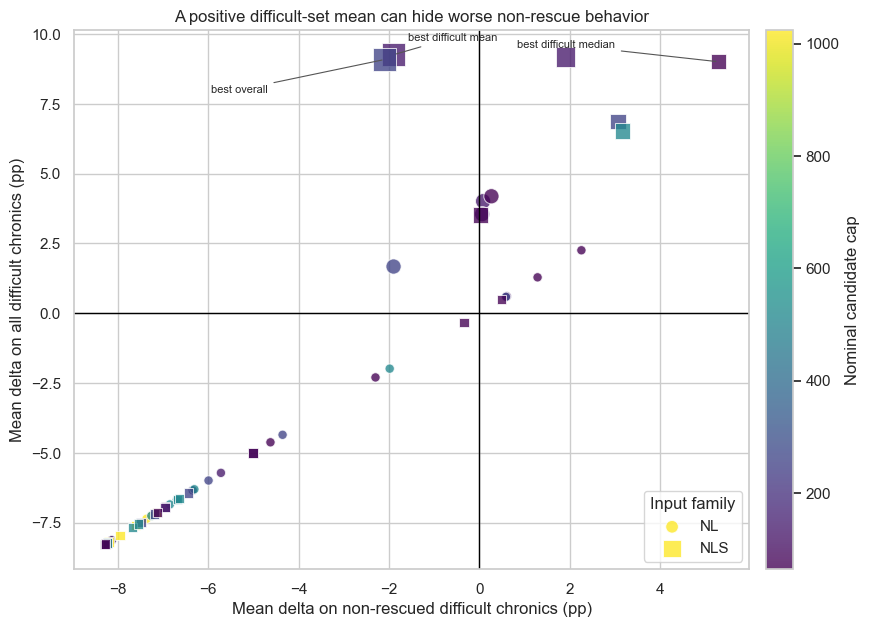

,run_id,difficult_mean_survival_percent,difficult_median_survival_percent,difficult_mean_delta_pp,difficult_nonrescue_mean_delta_pp,difficult_win_rate,difficult_loss_rate,difficult_rescues
0,NLS_mk256_tmean_f0_a0h0_s0,17.432,5.272,9.092,-2.093,0.250,0.583,3
1,NLS_mk128_tmean_f0_a0h0_s0,17.604,5.296,9.264,-1.897,0.250,0.542,3
2,NLS_mk64_mean_f1_a0h0_s0,17.349,7.399,9.009,5.293,0.375,0.250,1


In [4]:
plot_df = run_behavior.copy()
fig, ax = plt.subplots(figsize=(10.5, 7.0))
marker_map = {"NL": "o", "NLS": "s"}
for family, group in plot_df.groupby("family"):
    sizes = 45 + 75 * group["difficult_rescues"]
    scatter = ax.scatter(
        group["difficult_nonrescue_mean_delta_pp"],
        group["difficult_mean_delta_pp"],
        s=sizes,
        c=group["action_size"],
        cmap="viridis",
        vmin=min(ACTION_ORDER),
        vmax=max(ACTION_ORDER),
        marker=marker_map[family],
        alpha=0.78,
        edgecolor="white",
        linewidth=0.7,
        label=family,
    )
ax.axhline(0, color="black", linewidth=1)
ax.axvline(0, color="black", linewidth=1)
annotation_specs = {
    best_overall_id: ("best overall", (-125, -24)),
    best_hard_mean_id: ("best difficult mean", (10, 10)),
    best_hard_median_id: ("best difficult median", (-145, 10)),
}
for run_id, (annotation, offset) in annotation_specs.items():
    row = plot_df.loc[plot_df["run_id"] == run_id].iloc[0]
    ax.annotate(
        annotation,
        (row["difficult_nonrescue_mean_delta_pp"], row["difficult_mean_delta_pp"]),
        xytext=offset, textcoords="offset points", fontsize=8,
        arrowprops={"arrowstyle": "-", "color": "#555555", "linewidth": 0.8},
    )
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Nominal candidate cap")
ax.set(
    xlabel="Mean delta on non-rescued difficult chronics (pp)",
    ylabel="Mean delta on all difficult chronics (pp)",
    title="A positive difficult-set mean can hide worse non-rescue behavior",
)
ax.legend(title="Input family", loc="lower right")
save_figure(fig, "rescue_inflation_scatter")
plt.show()

selected_failure_metrics = difficult.set_index("run_id").loc[
    list(dict.fromkeys([best_overall_id, best_hard_mean_id, best_hard_median_id]))
].reset_index()[[
    "run_id", "difficult_mean_survival_percent",
    "difficult_median_survival_percent", "difficult_mean_delta_pp",
    "difficult_nonrescue_mean_delta_pp", "difficult_win_rate",
    "difficult_loss_rate", "difficult_rescues",
]]
display(selected_failure_metrics)


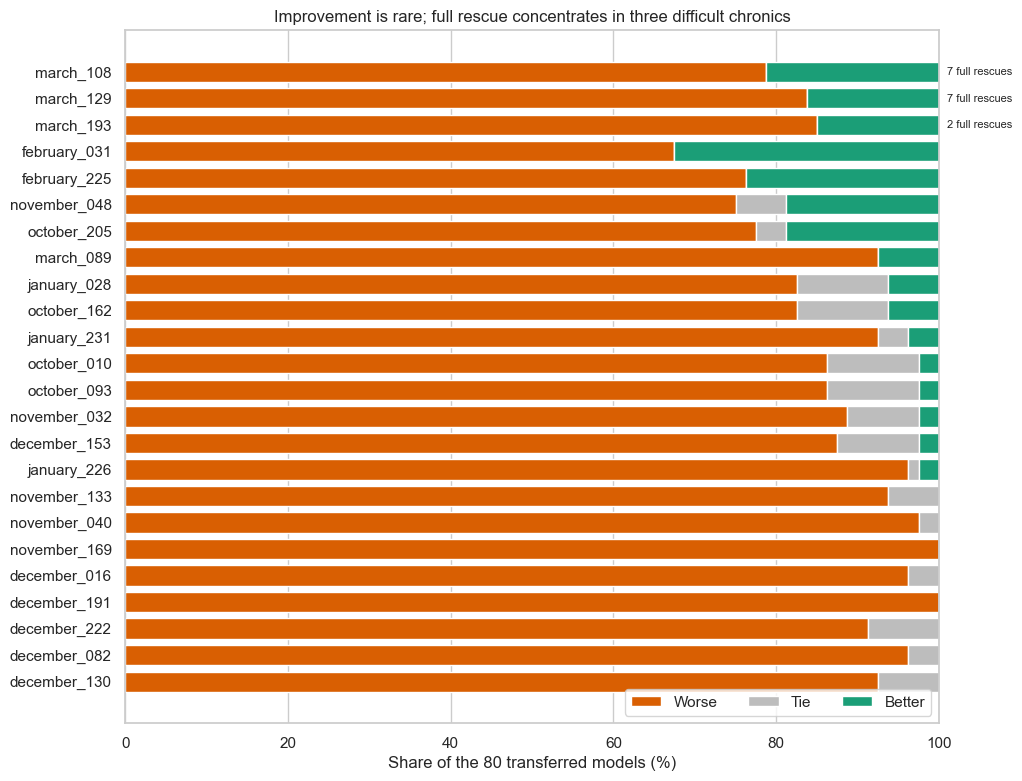

Across **80 models × 24 difficult chronics**, all **16** full-rescue events occur in only **3/24 chronics**. The remaining **21** difficult chronics are never fully rescued.

,chronic_fingerprint,chronic_name,do_nothing_survival,models_better,models_worse,full_rescues,mean_model_delta_pp,median_model_delta_pp,models_tied
23,9c117b745d3f,Scenario_march_108,0.055,17,63,7,9.086,-4.962,0
22,757491df7ead,Scenario_march_129,0.161,13,67,7,-0.874,-15.635,0
21,fe722f549427,Scenario_march_193,0.162,12,68,2,-6.908,-15.629,0
1,5c84a2d184d7,Scenario_december_082,0.119,0,77,0,-8.583,-11.691,3
20,874258b6547b,Scenario_february_031,0.012,26,54,0,0.273,-0.750,0
19,471f31a3df26,Scenario_february_225,0.012,19,61,0,-0.372,-0.775,0
18,cf9483360377,Scenario_november_048,0.019,15,60,0,-0.827,-1.488,5
17,c2c36dacfde1,Scenario_october_205,0.060,15,62,0,-4.101,-5.445,3


In [5]:
chronic_landscape = (
    hard.groupby(["chronic_fingerprint", "chronic_name", "do_nothing_survival"], as_index=False)
    .agg(
        models_better=("improved_vs_do_nothing", "sum"),
        models_worse=("worse_than_do_nothing", "sum"),
        full_rescues=("model_full_survival", "sum"),
        mean_model_delta_pp=("delta_vs_do_nothing_pp", "mean"),
        median_model_delta_pp=("delta_vs_do_nothing_pp", "median"),
    )
)
chronic_landscape["models_tied"] = (
    80 - chronic_landscape["models_better"] - chronic_landscape["models_worse"]
)
chronic_landscape = chronic_landscape.sort_values(
    ["full_rescues", "models_better", "do_nothing_survival"],
    ascending=[True, True, False],
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10.5, 9.0))
y = np.arange(len(chronic_landscape))
left = np.zeros(len(chronic_landscape))
for column, label, color in [
    ("models_worse", "Worse", "#D95F02"),
    ("models_tied", "Tie", "#BDBDBD"),
    ("models_better", "Better", "#1B9E77"),
]:
    width = 100 * chronic_landscape[column] / 80
    ax.barh(y, width, left=left, label=label, color=color, height=0.76)
    left += width
labels = [name.replace("Scenario_", "") for name in chronic_landscape["chronic_name"]]
ax.set_yticks(y, labels)
ax.set_xlim(0, 100)
ax.set_xlabel("Share of the 80 transferred models (%)")
ax.set_title("Improvement is rare; full rescue concentrates in three difficult chronics")
ax.legend(ncol=3, loc="lower right")
for index, row in chronic_landscape.iterrows():
    if row["full_rescues"]:
        ax.text(
            101, index, f"{int(row['full_rescues'])} full rescues",
            va="center", fontsize=8, clip_on=False,
        )
save_figure(fig, "difficult_chronic_generalization")
plt.show()

rescued_chronics = int((chronic_landscape["full_rescues"] > 0).sum())
total_rescues = int(chronic_landscape["full_rescues"].sum())
display(Markdown(
    f"Across **80 models × 24 difficult chronics**, all **{total_rescues}** full-rescue "
    f"events occur in only **{rescued_chronics}/24 chronics**. The remaining "
    f"**{24 - rescued_chronics}** difficult chronics are never fully rescued."
))
display(chronic_landscape.sort_values("full_rescues", ascending=False).head(8))


## 4. Candidate-set growth produces an intervention pathology

The source scorer was optimized while comparing at most 89 candidate
logits per agent. At transfer, do-nothing competes with hundreds or
thousands of target candidates. Even if individual erroneous high
scores are rare, the maximum over a larger set is more likely to beat
the do-nothing score. This is an **extreme-value/calibration
hypothesis**; the behavioral signature below is consistent with it.


,action_size,mean_survival_percent,median_survival_percent,best_survival_percent,mean_delta_pp
0,64,25.329,9.462,58.002,-30.674
1,128,19.846,1.565,58.976,-36.158
2,256,16.951,1.236,59.748,-39.052
3,512,13.174,1.328,56.493,-42.829
4,1024,3.238,0.403,39.750,-52.766


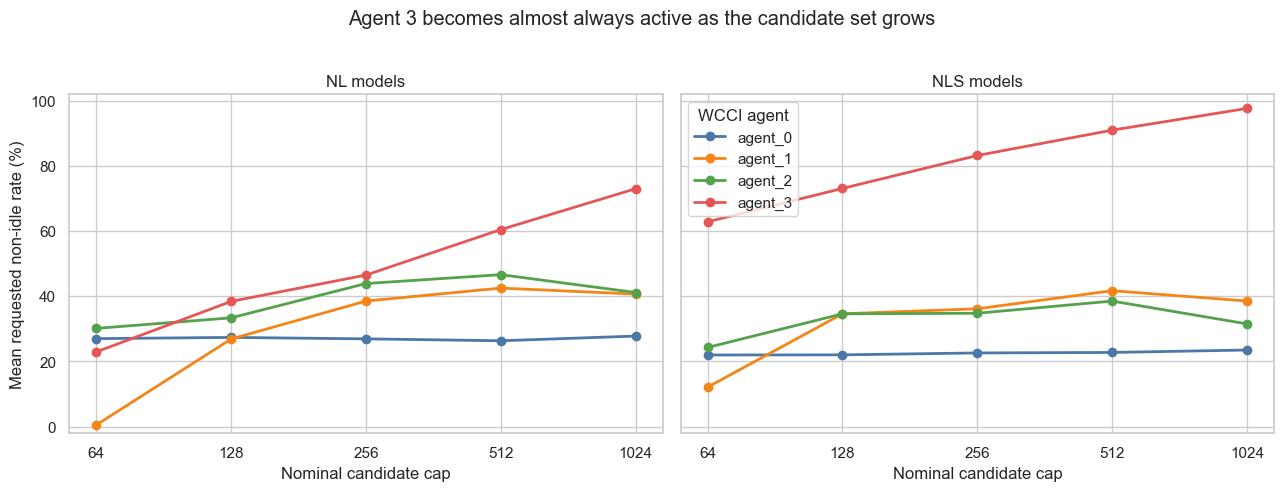

For NLS at cap 1,024, **agent 3 requests a non-idle action on 97.7% of evaluated steps on average** across the eight variants.

In [6]:
cap_performance = (
    ranking.groupby("action_size", as_index=False)
    .agg(
        mean_survival_percent=("mean_survival_percent", "mean"),
        median_survival_percent=("mean_survival_percent", "median"),
        best_survival_percent=("mean_survival_percent", "max"),
        mean_delta_pp=("delta_vs_do_nothing_pp", "mean"),
    )
    .sort_values("action_size")
)
display(cap_performance)

agent_by_cap = (
    agent_behavior.groupby(["family", "action_size", "agent_id"], as_index=False)
    .agg(mean_nonidle_fraction=("nonidle_fraction", "mean"))
)
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8), sharey=True)
for ax, family in zip(axes, ["NL", "NLS"]):
    family_df = agent_by_cap.loc[agent_by_cap["family"] == family]
    for agent_id, group in family_df.groupby("agent_id"):
        group = group.sort_values("action_size")
        ax.plot(
            group["action_size"], 100 * group["mean_nonidle_fraction"],
            marker="o", linewidth=2, color=AGENT_COLORS[agent_id], label=agent_id,
        )
    ax.set_xscale("log", base=2)
    ax.set_xticks(ACTION_ORDER, ACTION_ORDER)
    ax.set_ylim(-2, 102)
    ax.set_title(f"{family} models")
    ax.set_xlabel("Nominal candidate cap")
axes[0].set_ylabel("Mean requested non-idle rate (%)")
axes[1].legend(title="WCCI agent", loc="upper left")
fig.suptitle("Agent 3 becomes almost always active as the candidate set grows", y=1.02)
fig.tight_layout()
save_figure(fig, "agent_intervention_rate_by_cap")
plt.show()

agent3_nls_1024 = agent_by_cap.loc[
    (agent_by_cap["family"] == "NLS")
    & (agent_by_cap["action_size"] == 1024)
    & (agent_by_cap["agent_id"] == "agent_3"),
    "mean_nonidle_fraction",
].iloc[0]
display(Markdown(
    f"For NLS at cap 1,024, **agent 3 requests a non-idle action on "
    f"{100 * agent3_nls_1024:.1f}% of evaluated steps on average** across the eight variants."
))


,behavior_metric,pearson_r_with_survival
2,Mean non-idle action entropy,-0.517
0,Mean non-idle rate,-0.515
1,Maximum agent non-idle rate,-0.492
3,Agent non-idle imbalance,-0.386
5,Candidate cap,-0.320
4,Top-action concentration,0.507


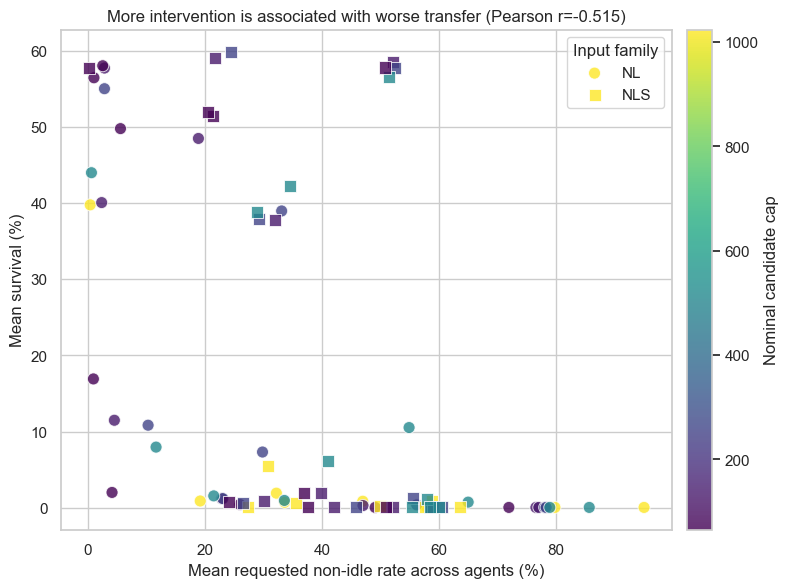

,survival_quartile,models,mean_survival_percent,mean_nonidle_fraction,max_agent_nonidle_fraction
0,bottom,20,0.055,0.654,0.949
1,lower-middle,20,0.493,0.432,0.899
2,upper-middle,20,10.262,0.284,0.643
3,top,20,52.020,0.200,0.460


In [7]:
correlation_columns = {
    "mean_nonidle_fraction": "Mean non-idle rate",
    "max_agent_nonidle_fraction": "Maximum agent non-idle rate",
    "mean_nonidle_entropy_bits": "Mean non-idle action entropy",
    "nonidle_imbalance": "Agent non-idle imbalance",
    "mean_top_nonidle_share": "Top-action concentration",
    "action_size": "Candidate cap",
}
correlation_table = pd.DataFrame([
    {
        "behavior_metric": label,
        "pearson_r_with_survival": run_behavior[column].corr(
            run_behavior["mean_survival_percent"]
        ),
    }
    for column, label in correlation_columns.items()
]).sort_values("pearson_r_with_survival")
display(correlation_table)

fig, ax = plt.subplots(figsize=(9.5, 6.5))
markers = {"NL": "o", "NLS": "s"}
for family, group in run_behavior.groupby("family"):
    scatter = ax.scatter(
        100 * group["mean_nonidle_fraction"],
        group["mean_survival_percent"],
        c=group["action_size"], cmap="viridis",
        vmin=min(ACTION_ORDER), vmax=max(ACTION_ORDER),
        marker=markers[family], s=75, alpha=0.8,
        edgecolor="white", linewidth=0.7, label=family,
    )
correlation = run_behavior["mean_nonidle_fraction"].corr(
    run_behavior["mean_survival_percent"]
)
ax.set(
    xlabel="Mean requested non-idle rate across agents (%)",
    ylabel="Mean survival (%)",
    title=f"More intervention is associated with worse transfer (Pearson r={correlation:.3f})",
)
ax.legend(title="Input family")
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("Nominal candidate cap")
save_figure(fig, "survival_vs_intervention_rate")
plt.show()

quartiles = pd.qcut(
    run_behavior["mean_survival_percent"], 4,
    labels=["bottom", "lower-middle", "upper-middle", "top"],
)
intervention_quartiles = (
    run_behavior.assign(survival_quartile=quartiles)
    .groupby("survival_quartile", observed=True, as_index=False)
    .agg(
        models=("run_id", "size"),
        mean_survival_percent=("mean_survival_percent", "mean"),
        mean_nonidle_fraction=("mean_nonidle_fraction", "mean"),
        max_agent_nonidle_fraction=("max_agent_nonidle_fraction", "mean"),
    )
)
display(intervention_quartiles)


## 5. The best mean model is not the most robust model

This table compares the do-nothing baseline, the best overall
transferred mean, the transferred model with the best difficult-set
median, and an already available target-trained WCCI MLP. “Easy
preservation” is the fraction of the 26 do-nothing-perfect chronics
on which the model also survives fully.


In [8]:
baseline_by_fingerprint = (
    episodes[[
        "chronic_fingerprint", "chronic_name", "do_nothing_survival",
        "do_nothing_full_survival", "cohort",
    ]]
    .drop_duplicates("chronic_fingerprint")
    .set_index("chronic_fingerprint")
)


def summarize_model_rows(label, frame):
    frame = frame.copy()
    hard_rows = frame.loc[frame["cohort"] == "Do-nothing < 100%"]
    easy_rows = frame.loc[frame["cohort"] == "Do-nothing = 100%"]
    return {
        "model": label,
        "overall_mean_survival_percent": 100 * frame["survival"].mean(),
        "easy_mean_survival_percent": 100 * easy_rows["survival"].mean(),
        "easy_preservation_rate": easy_rows["model_full_survival"].mean(),
        "difficult_mean_survival_percent": 100 * hard_rows["survival"].mean(),
        "difficult_median_survival_percent": 100 * hard_rows["survival"].median(),
        "difficult_mean_delta_pp": hard_rows["delta_vs_do_nothing_pp"].mean(),
        "difficult_win_rate": hard_rows["improved_vs_do_nothing"].mean(),
        "difficult_loss_rate": hard_rows["worse_than_do_nothing"].mean(),
        "difficult_full_rescues": int(hard_rows["model_full_survival"].sum()),
    }


comparison_rows = [{
    "model": "Do nothing",
    "overall_mean_survival_percent": 100 * baseline_by_fingerprint["do_nothing_survival"].mean(),
    "easy_mean_survival_percent": 100.0,
    "easy_preservation_rate": 1.0,
    "difficult_mean_survival_percent": 100 * baseline_by_fingerprint.loc[
        baseline_by_fingerprint["cohort"] == "Do-nothing < 100%", "do_nothing_survival"
    ].mean(),
    "difficult_median_survival_percent": 100 * baseline_by_fingerprint.loc[
        baseline_by_fingerprint["cohort"] == "Do-nothing < 100%", "do_nothing_survival"
    ].median(),
    "difficult_mean_delta_pp": 0.0,
    "difficult_win_rate": np.nan,
    "difficult_loss_rate": np.nan,
    "difficult_full_rescues": 0,
}]

for label, run_id in [
    (f"Best overall: {best_overall_id}", best_overall_id),
    (f"Best difficult median: {best_hard_median_id}", best_hard_median_id),
]:
    comparison_rows.append(summarize_model_rows(
        label, episodes.loc[episodes["run_id"] == run_id]
    ))

mlp_path = (
    TASK_DIR / "outputs" / "full_test_eval_actions"
    / "best_test_wcci_reduced_mlp_baseline_72x576_s0_50chronics"
    / "episode_summary.csv"
)
if mlp_path.is_file():
    mlp = pd.read_csv(mlp_path).merge(
        baseline_by_fingerprint.reset_index(),
        on="chronic_fingerprint", validate="one_to_one",
    )
    mlp["model_full_survival"] = np.isclose(mlp["survival"], 1.0)
    mlp["delta_vs_do_nothing_pp"] = 100 * (
        mlp["survival"] - mlp["do_nothing_survival"]
    )
    mlp["improved_vs_do_nothing"] = mlp["delta_vs_do_nothing_pp"] > 1e-9
    mlp["worse_than_do_nothing"] = mlp["delta_vs_do_nothing_pp"] < -1e-9
    comparison_rows.append(summarize_model_rows("Target-trained WCCI MLP", mlp))

representative_comparison = pd.DataFrame(comparison_rows)
display(representative_comparison)


,model,overall_mean_survival_percent,easy_mean_survival_percent,easy_preservation_rate,difficult_mean_survival_percent,difficult_median_survival_percent,difficult_mean_delta_pp,difficult_win_rate,difficult_loss_rate,difficult_full_rescues
0,Do nothing,56.003,100.000,1.000,8.340,5.991,0.000,NaN,NaN,0
1,Best overall: NLS_mk256_tmean_f0_a0h0_s0,59.748,98.810,0.962,17.432,5.272,9.092,0.250,0.583,3
2,Best difficult median: NLS_mk64_mean_f1_a0h0_s0,57.769,95.080,0.885,17.349,7.399,9.009,0.375,0.250,1
3,Target-trained WCCI MLP,19.033,25.446,0.038,12.087,6.065,3.746,0.417,0.583,0


In [9]:
best_overall_hard = hard.loc[hard["run_id"] == best_overall_id].copy()
rescued = best_overall_hard["model_full_survival"]
rescue_contribution_total_pp = (
    best_overall_hard.loc[rescued, "delta_vs_do_nothing_pp"].sum() / 50
)
nonrescue_contribution_total_pp = (
    best_overall_hard.loc[~rescued, "delta_vs_do_nothing_pp"].sum() / 50
)
easy_contribution_total_pp = (
    easy.loc[easy["run_id"] == best_overall_id, "delta_vs_do_nothing_pp"].sum() / 50
)
overall_delta = ranking.set_index("run_id").loc[best_overall_id, "delta_vs_do_nothing_pp"]

contribution_table = pd.DataFrame([
    {"component": "Fully rescued difficult chronics", "episodes": int(rescued.sum()),
     "contribution_to_50_episode_mean_pp": rescue_contribution_total_pp},
    {"component": "Other difficult chronics", "episodes": int((~rescued).sum()),
     "contribution_to_50_episode_mean_pp": nonrescue_contribution_total_pp},
    {"component": "Do-nothing-perfect chronics", "episodes": 26,
     "contribution_to_50_episode_mean_pp": easy_contribution_total_pp},
])
display(contribution_table)
assert np.isclose(
    contribution_table["contribution_to_50_episode_mean_pp"].sum(), overall_delta
)
display(Markdown(
    f"For **{best_overall_id}**, the {int(rescued.sum())} full rescues add "
    f"**{rescue_contribution_total_pp:.3f} pp** to the 50-episode mean. "
    f"The other difficult chronics contribute **{nonrescue_contribution_total_pp:.3f} pp** "
    f"and the easy chronics **{easy_contribution_total_pp:.3f} pp**, yielding "
    f"the reported **{overall_delta:.3f} pp** advantage over do-nothing."
))


,component,episodes,contribution_to_50_episode_mean_pp
0,Fully rescued difficult chronics,3,5.243
1,Other difficult chronics,21,-0.879
2,Do-nothing-perfect chronics,26,-0.619


For **NLS_mk256_tmean_f0_a0h0_s0**, the 3 full rescues add **5.243 pp** to the 50-episode mean. The other difficult chronics contribute **-0.879 pp** and the easy chronics **-0.619 pp**, yielding the reported **3.745 pp** advantage over do-nothing.

## 6. Root-cause assessment

Confidence is based on how directly the saved data support a claim.
“High” means the failure signature is measured; it does not mean that
an observational correlation proves the internal causal mechanism.


In [10]:
nonidle_corr = run_behavior["mean_nonidle_fraction"].corr(
    run_behavior["mean_survival_percent"]
)
cap64_mean = cap_performance.set_index("action_size").loc[64, "mean_survival_percent"]
cap1024_mean = cap_performance.set_index("action_size").loc[1024, "mean_survival_percent"]
source_max = int(source_candidate_counts["candidate_count"].max())
target_max = int(target_candidate_counts["candidate_count"].max())

root_causes = pd.DataFrame([
    {
        "candidate_failure_mode": "Candidate-cardinality / do-nothing calibration shift",
        "confidence": "High signature; mechanism still to ablate",
        "evidence": (
            f"Source agents saw at most {source_max} candidates; target agents see up to "
            f"{target_max}. Across-model mean survival falls from {cap64_mean:.2f}% at cap 64 "
            f"to {cap1024_mean:.2f}% at cap 1024, while NLS agent 3 reaches "
            f"{100 * agent3_nls_1024:.1f}% non-idle."
        ),
        "next_test": "Log action0/top-1 margins; subtract a size-aware offset or gate act/no-act before ranking.",
    },
    {
        "candidate_failure_mode": "Over-intervention and cross-agent imbalance",
        "confidence": "High behavioral evidence",
        "evidence": (
            f"Mean non-idle rate correlates {nonidle_corr:.3f} with survival; one target agent "
            "often acts nearly every step, unlike the source setup with only three agents."
        ),
        "next_test": "Evaluate rho-gated intervention and report per-agent non-idle, cooldown, and legality rates.",
    },
    {
        "candidate_failure_mode": "Narrow chronic-specific policy rather than broad robustness",
        "confidence": "High outcome evidence",
        "evidence": (
            f"All {total_rescues} full rescues across 80 models occur in only "
            f"{rescued_chronics}/24 difficult chronics. The best mean model is worse on its "
            "non-rescued difficult cases."
        ),
        "next_test": "Select checkpoints by difficult median/win rate plus easy preservation, not only mean survival.",
    },
    {
        "candidate_failure_mode": "Illegal/cooldown-incompatible repeated actions",
        "confidence": "Plausible but not measured",
        "evidence": (
            "Saved summaries contain requested action IDs but no illegal/ambiguous/cooldown outcome. "
            "Full action traces were disabled."
        ),
        "next_test": "Add is_illegal, is_ambiguous, cooldown state, executed topology change, and rho before/after to traces.",
    },
    {
        "candidate_failure_mode": "Observation/representation domain shift",
        "confidence": "Medium; qualitative companion evidence",
        "evidence": (
            "The source and target grids differ in size, a fourth agent appears, and an existing bus14-vs-WCCI "
            "feature audit found power/angle distribution shifts. Current zero-shot runs do not adapt running statistics."
        ),
        "next_test": "Measure the exact hetero-line actor inputs on both grids; test target-stat calibration and multi-grid pretraining.",
    },
])
display(root_causes)


,candidate_failure_mode,confidence,evidence,next_test
0,Candidate-cardinality / do-nothing calibration...,High signature; mechanism still to ablate,Source agents saw at most 89 candidates; targe...,Log action0/top-1 margins; subtract a size-awa...
1,Over-intervention and cross-agent imbalance,High behavioral evidence,Mean non-idle rate correlates -0.515 with surv...,Evaluate rho-gated intervention and report per...
2,Narrow chronic-specific policy rather than bro...,High outcome evidence,All 16 full rescues across 80 models occur in ...,Select checkpoints by difficult median/win rat...
3,Illegal/cooldown-incompatible repeated actions,Plausible but not measured,Saved summaries contain requested action IDs b...,"Add is_illegal, is_ambiguous, cooldown state, ..."
4,Observation/representation domain shift,Medium; qualitative companion evidence,"The source and target grids differ in size, a ...",Measure the exact hetero-line actor inputs on ...


## 7. What to do next

The order below prioritizes experiments that distinguish mechanisms
before expensive retraining. The ongoing WCCI fine-tune/from-scratch
evaluations answer the last row, but they should be judged with the
robust metrics in this notebook—not only the 50-episode mean.


In [11]:
prioritized_experiments = pd.DataFrame([
    {
        "priority": "P0",
        "experiment": "Diagnostic traces on representative easy and difficult chronics",
        "change": (
            "Save action ID, action0 and top-1 logits/margin, rho before/after, cooldown, "
            "illegal/ambiguous flags, and whether the topology actually changed."
        ),
        "decision": "Confirms whether failure is miscalibration, illegality, ineffective repetition, or harmful legal actions.",
    },
    {
        "priority": "P0",
        "experiment": "Evaluation-only rho intervention gate",
        "change": "For the best overall and robust cap-64 model, sweep rho thresholds 0.85/0.90/0.95/1.00.",
        "decision": "A large easy-preservation gain with stable hard performance validates over-intervention as a primary issue.",
    },
    {
        "priority": "P1",
        "experiment": "Two-stage act/no-act policy",
        "change": (
            "Predict a candidate-count-independent intervention decision first; rank non-idle actions only after act is selected."
        ),
        "decision": "Removes the maximum-over-N competition between action0 and hundreds of target actions.",
    },
    {
        "priority": "P1",
        "experiment": "Legality/cooldown mask before sampling or argmax",
        "change": "Mask candidates that cannot execute in the current Grid2Op state and expose a valid do-nothing fallback.",
        "decision": "Should eliminate repeated impossible actions if trace diagnostics show they are common.",
    },
    {
        "priority": "P1",
        "experiment": "Variable-cardinality and hard-negative training",
        "change": (
            "Randomly subsample candidate sets during training, include large sets, and train an action0-vs-best-action margin."
        ),
        "decision": "Tests whether the shared scorer can remain calibrated as candidate count and agent identity change.",
    },
    {
        "priority": "P1",
        "experiment": "Robust checkpoint selection",
        "change": (
            "Rank by difficult median/win rate and easy preservation, with mean survival as a secondary metric."
        ),
        "decision": "Prevents three rare rescues from selecting a checkpoint that degrades most non-rescued cases.",
    },
    {
        "priority": "P2",
        "experiment": "Teacher distillation or top-M simulator reranking",
        "change": (
            "Learn target action improvement versus do-nothing from the WCCI teacher data, or simulate only the learned top-M candidates."
        ),
        "decision": "Separates whether useful candidates are absent from the ranker's top choices or intrinsically unavailable.",
    },
    {
        "priority": "P2",
        "experiment": "WCCI fine-tune versus scratch versus zero-shot",
        "change": "Use identical action space, split, checkpoint metric, and robust/easy metrics for all three regimes.",
        "decision": "Quantifies useful source knowledge versus negative transfer after target adaptation.",
    },
])
display(prioritized_experiments)


,priority,experiment,change,decision
0,P0,Diagnostic traces on representative easy and d...,"Save action ID, action0 and top-1 logits/margi...","Confirms whether failure is miscalibration, il..."
1,P0,Evaluation-only rho intervention gate,"For the best overall and robust cap-64 model, ...",A large easy-preservation gain with stable har...
2,P1,Two-stage act/no-act policy,Predict a candidate-count-independent interven...,Removes the maximum-over-N competition between...
3,P1,Legality/cooldown mask before sampling or argmax,Mask candidates that cannot execute in the cur...,Should eliminate repeated impossible actions i...
4,P1,Variable-cardinality and hard-negative training,Randomly subsample candidate sets during train...,Tests whether the shared scorer can remain cal...
5,P1,Robust checkpoint selection,Rank by difficult median/win rate and easy pre...,Prevents three rare rescues from selecting a c...
6,P2,Teacher distillation or top-M simulator reranking,Learn target action improvement versus do-noth...,Separates whether useful candidates are absent...
7,P2,WCCI fine-tune versus scratch versus zero-shot,"Use identical action space, split, checkpoint ...",Quantifies useful source knowledge versus nega...


## 8. Export reproducible tables and conclusions


In [12]:
agent_behavior.to_csv(EXPORT_DIR / "agent_behavior_metrics.csv", index=False)
run_behavior.to_csv(EXPORT_DIR / "run_behavior_metrics.csv", index=False)
candidate_counts.to_csv(EXPORT_DIR / "candidate_cardinality.csv", index=False)
chronic_landscape.to_csv(EXPORT_DIR / "difficult_chronic_failure_landscape.csv", index=False)
selected_failure_metrics.to_csv(EXPORT_DIR / "selected_failure_metrics.csv", index=False)
correlation_table.to_csv(EXPORT_DIR / "behavior_survival_correlations.csv", index=False)
intervention_quartiles.to_csv(EXPORT_DIR / "intervention_by_survival_quartile.csv", index=False)
representative_comparison.to_csv(EXPORT_DIR / "representative_model_comparison.csv", index=False)
contribution_table.to_csv(EXPORT_DIR / "best_overall_mean_contributions.csv", index=False)
root_causes.to_csv(EXPORT_DIR / "root_cause_evidence.csv", index=False)
prioritized_experiments.to_csv(EXPORT_DIR / "prioritized_experiments.csv", index=False)

summary = f'''# Zero-shot transfer failure summary

- Dataset: 80 transferred models × 50 WCCI test chronics.
- Difficult cohort: 24 chronics on which do-nothing fails before the horizon.
- Best overall model: `{best_overall_id}`.
- Best difficult-median model: `{best_hard_median_id}`.
- Full rescues: {total_rescues}, concentrated in {rescued_chronics}/24 difficult chronics.
- Candidate mismatch: source maximum {source_max}; WCCI target maximum {target_max}.
- Across-model mean survival: {cap64_mean:.3f}% at cap 64 versus {cap1024_mean:.3f}% at cap 1024.
- NLS agent-3 non-idle rate at cap 1024: {100 * agent3_nls_1024:.3f}%.
- Correlation of mean non-idle rate with survival: r={nonidle_corr:.3f} (descriptive, not causal).
- Best-overall rescue contribution: {rescue_contribution_total_pp:.3f} pp of the 50-episode mean.

Primary next step: collect legality/cooldown/logit-margin traces and run an evaluation-only rho-gate sweep before changing the architecture.
'''
(EXPORT_DIR / "failure_summary.md").write_text(summary, encoding="utf-8")

display(Markdown(
    "### Bottom line\n\n"
    "The zero-shot model is not simply *incapable of acting*: it can rescue a few "
    "specific failures. The dominant problem is that this ability does not generalize, "
    "while candidate-set growth makes the policy intervene too often and asymmetrically. "
    "The safest path is therefore to decouple **whether to act** from **which action to "
    "take**, mask invalid actions, train/calibrate across candidate-set sizes, and select "
    "checkpoints with robust difficult-chronic and easy-preservation metrics."
))
print("Exported analysis to:", EXPORT_DIR)


### Bottom line

The zero-shot model is not simply *incapable of acting*: it can rescue a few specific failures. The dominant problem is that this ability does not generalize, while candidate-set growth makes the policy intervene too often and asymmetrically. The safest path is therefore to decouple **whether to act** from **which action to take**, mask invalid actions, train/calibrate across candidate-set sizes, and select checkpoints with robust difficult-chronic and easy-preservation metrics.

Exported analysis to: /Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task/outputs/analysis/shared_zero_shot_failure_analysis
